In [11]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import ttest_ind
from natsort import natsorted
from sklearn.decomposition import PCA
import nibabel.freesurfer.io as fsio
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
import glob
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import pearsonr
import os
from scipy.stats import linregress
from sklearn.decomposition import PCA
from scipy.stats import ttest_ind
from sklearn.metrics import pairwise_distances
import seaborn as sns
from nibabel import cifti2
from scipy.spatial import procrustes
from scipy.stats import ttest_ind
import nibabel as nib
np.random.seed(42)
from brainspace.null_models import SpinPermutations

In [12]:
geodesicA1 = pd.read_csv('../Derivatives/human_A1_schaefer.csv')
geodesicA1 = geodesicA1[geodesicA1['Index']!=0].dist.values
geodesicV1 = pd.read_csv('../Derivatives/human_V1_schaefer.csv')
geodesicV1 = geodesicV1[geodesicV1['Index']!=0].dist.values
SA = pd.read_csv('../Dataset/Sensorimotor_Association_Axis_AverageRanks.csv')

In [13]:
labels, ctab, names = nib.freesurfer.read_annot('../Dataset/template/rh.HCPMMP1.annot')
roi_names = [name.decode('utf-8') for name in names]
MMPname = roi_names[1:]
pd.DataFrame(MMPname).to_csv('../Dataset/template/MMPregions.csv', index=False)
lut = pd.DataFrame(MMPname)
auditory_rois = [
    "R_A1_ROI","R_MBelt_ROI","R_LBelt_ROI","R_PBelt_ROI",
    "R_TA2_ROI","R_STGa_ROI","R_STSva_ROI","R_PI_ROI","R_RI_ROI"
]
auditory_ids = lut[lut[0].isin(auditory_rois)].index.values + 1
auditory_ids = lut[lut[0].isin(auditory_rois)].index.values + 1
auditory_regionid = [i+1 for i in np.arange(len(MMPname)) if MMPname[i] in ["R_A1_ROI","R_MBelt_ROI","R_LBelt_ROI","R_PBelt_ROI","R_STGa_ROI","R_STSva_ROI"]]#,

In [14]:
region_label = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 9, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 7, 9, 7, 9, 7, 7, 7, 7,
       7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 8, 8,
       8, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 9, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 4, 9, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 9, 5, 5, 5, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6,
       6, 6, 6, 6, 6, 9, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9,
       7, 9, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 9, 9, 9, 8, 8, 8,
       8, 8, 8, 8]

network_names = ['surf_area_mm2', 'avg_thickness_mm','curvature_index']
labels = [f"{i}_{j}" for i in network_names for j in network_names]

In [15]:
# Paths to fsaverage5 or fsaverage (you may adjust)
annot_dir = '../Dataset/template/'  # Your Schaefer annotation directory
# Load surfaces
coords_lh, faces_lh = nib.freesurfer.read_geometry(annot_dir + 'lh.inflated')  # or .white/.pial
coords_rh, faces_rh = nib.freesurfer.read_geometry(annot_dir + 'rh.inflated')
# Load annotations (Schaefer)
labels_lh, ctab_lh, names_lh = nib.freesurfer.read_annot(annot_dir + 'lh.Schaefer2018_400Parcels_17Networks_order.annot')
labels_rh, ctab_rh, names_rh = nib.freesurfer.read_annot(annot_dir + 'rh.Schaefer2018_400Parcels_17Networks_order.annot')
# Unique label values (exclude medial wall = 0)
unique_labels_lh = np.unique(labels_lh[labels_lh != 0])
unique_labels_rh = np.unique(labels_rh[labels_rh != 0])
# Compute centroids (mean coordinate of all vertices in each parcel)
centroids_lh = np.array([coords_lh[labels_lh == label].mean(axis=0) for label in unique_labels_lh])
centroids_rh = np.array([coords_rh[labels_rh == label].mean(axis=0) for label in unique_labels_rh])
# Combine
centroids = np.vstack((centroids_lh, centroids_rh))  # shape = (n_parcels, 3)

In [16]:
for t in [geodesicA1, geodesicV1]:
    sp = SpinPermutations(n_rep=10000, random_state=0)
    sp.fit(centroids)
    # Randomize data (already subset)
    spun_data_all = sp.randomize(t)
    # Calculate observed correlation
    obs_corr = np.corrcoef(t, SA['finalrank.wholebrain'].values)[0, 1]
    # Calculate null distribution correlations
    perm_corr = np.array([
        np.corrcoef(spun, SA['finalrank.wholebrain'].values)[0, 1]
        for spun in spun_data_all
    ])
    # Compute two-tailed p-value
    pval = np.mean(np.abs(perm_corr) >= np.abs(obs_corr))
    print(f"Observed correlation: {obs_corr:.3f} p-value: {pval:.4f}")

Observed correlation: -0.105 p-value: 0.6895
Observed correlation: 0.397 p-value: 0.1886


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Correlation coefficient: -0.10460550110447386, P-value: 0.03650088892917305
Correlation coefficient: 0.3968679797896766, P-value: 1.5326229555185677e-16


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


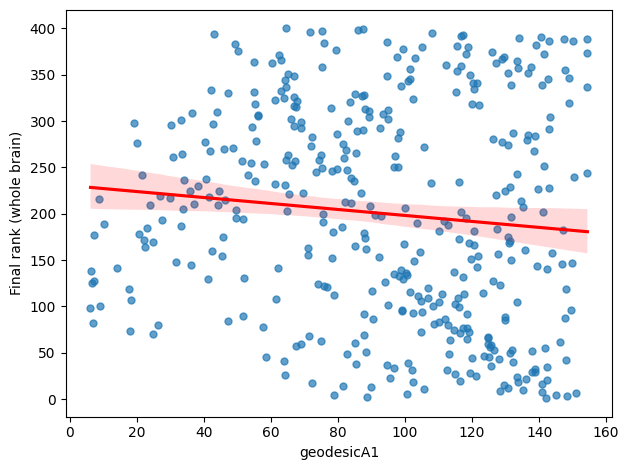

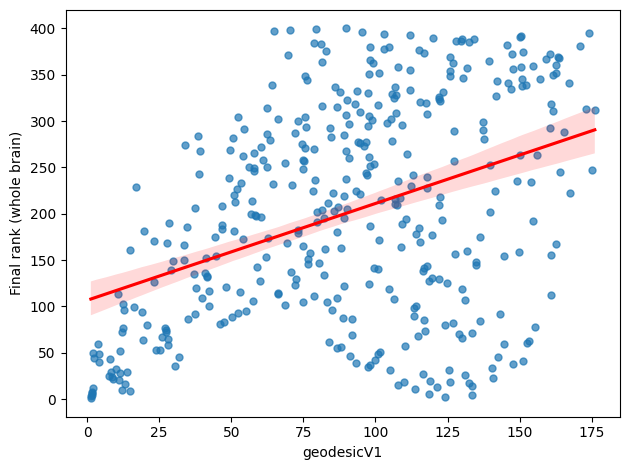

In [ ]:
titles = ['geodesicA1', 'geodesicV1']
for i,t in enumerate([geodesicA1, geodesicV1]):
    plt.figure()
    sns.regplot(
        x=t,
        y=SA['finalrank.wholebrain'],
        scatter_kws={'s': 25, 'alpha': 0.7},
        line_kws={'color': 'red'},
        ci=95
    )
    x=t
    y=SA['finalrank.wholebrain'].values
    r, p = pearsonr(x, y)
    print(f"Correlation coefficient: {r}, P-value: {p}")

    plt.xlabel(titles[i])
    plt.ylabel("Final rank (whole brain)")
    plt.tight_layout()

In [18]:
regions = [x.split(' - ')[1] for x in pd.read_csv('../Dataset/template/Wang/ROIfiles_Labeling.txt', sep='\t').index.values] + [x.split(' - ')[1] for x in pd.read_csv('../Dataset/template/Wang/ROIfiles_Labeling.txt', sep='\t').index.values]
regionid = [i+1 for i in np.arange(len(regions)) if regions[i] in ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'VO1', 'VO2', 'PHC1',  'LO1']] #, 'IPS2', 'IPS3', 'IPS4', 'SPL1', 'FEF']] #['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'VO1', 'VO2', 'PHC1', 'PHC2', 'LO1', 'LO2']

In [19]:
unique_labels = set()
auditory_id = []
with open("../Derivatives/auditory_Julich_schaefer_overlaps.txt", "r") as f:
    for line in f:
        # Split by ':' and then spaces, skip empty strings
        parts = line.strip().split(":")
        #if int(parts[0]) in auditory_regionid:
        if len(parts) > 1:
            numbers = parts[1].strip().split()
            unique_labels.update(map(int, numbers))
            auditory_id.append([int(i)-1 for i in numbers if int(i)>0])
unique_labels = [i-1 for i in unique_labels if i!=0 ]
auditory = [1 if i in unique_labels else 0 for i in np.arange(400)]
unique_labels = set()
with open("../Derivatives/wang_schaefer_overlaps.txt", "r") as f:
    for line in f:
        # Split by ':' and then spaces, skip empty strings
        parts = line.strip().split(":")
        #if int(parts[0]) in regionid:
        if len(parts) > 1:
            numbers = parts[1].strip().split()
            unique_labels.update(map(int, numbers))
unique_labels = [i-1 for i in unique_labels if i!=0 ]
visual = [1 if i in unique_labels else 0 for i in np.arange(400)]
unique_labels = set()
with open("../Derivatives/wang_schaefer_overlaps.txt", "r") as f:
    for line in f:
        # Split by ':' and then spaces, skip empty strings
        parts = line.strip().split(":")
        if int(parts[0]) < 3:
            if len(parts) > 1:
                numbers = parts[1].strip().split()
                unique_labels.update(map(int, numbers))
unique_labels = [i-1 for i in unique_labels if i!=0 ]
v1 = [1 if i in unique_labels else 0 for i in np.arange(400)]

In [20]:
deaf = pd.read_csv('../Derivatives/deaf_parcel_stats.tsv', sep='\t') #../derivatives/
blind = pd.read_csv('../Derivatives/blind_parcel_stats.tsv', sep='\t') #../derivatives/
deaf['label'] = [str(x)+'_'+str(y) for x,y in zip(deaf['hemi'], deaf['label'])]
blind['label'] = [str(x)+'_'+str(y) for x,y in zip(blind['hemi'], blind['label'])]

/tmp/ipykernel_1543197/1631095265.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  deaf = pd.read_csv('../Derivatives/deaf_parcel_stats.tsv', sep='\t') #../derivatives/


In [21]:
deaf_curvature = pd.read_csv('../Derivatives/deaf_curvature_index_vertexwise.tsv', sep='\t')
blind_curvature = pd.read_csv('../Derivatives/blind_curvature_index_vertexwise.tsv', sep='\t')

In [22]:
deaf_curvature['label'] = [x+'_'+y for x,y in zip(deaf_curvature['hemi'], deaf_curvature['label'])]
#deaf = pd.merge(deaf, deaf_curvature, on=['subject', 'hemi', 'parcellation',  'label'], how='left')
#deaf['curvature_index'] = deaf['curvature_index_y']
#deaf['surf_area_mm2'] = deaf['surface_area_mm2']

In [23]:
blind_curvature['label'] = [x+'_'+y for x,y in zip(blind_curvature['hemi'], blind_curvature['label'])]
#blind = pd.merge(blind, blind_curvature, on=['subject', 'hemi', 'parcellation', 'label'], how='left')
#blind['curvature_index'] = blind['curvature_index_y']
#blind['surf_area_mm2'] = blind['surface_area_mm2']

In [24]:
deaf = deaf[deaf.parcellation=='Schaefer2018_400Parcels_17Networks_order'].loc[:, ['subject','curvature_index','label', 'surf_area_mm2', 'avg_thickness_mm']].groupby(['subject', 'label']).mean().reset_index()
blind = blind[blind.parcellation=='Schaefer2018_400Parcels_17Networks_order'].loc[:, ['subject','curvature_index','label', 'surf_area_mm2', 'avg_thickness_mm']].groupby(['subject', 'label']).mean().reset_index()

In [25]:
all_dfs = {}
for x in ['surf_area_mm2', 'avg_thickness_mm','curvature_index']:
    df_blind = blind.pivot(index='subject', columns='label', values=x).reset_index()
    df_blind = df_blind.loc[:, ['subject']+list(SA.label.values)]
    df_blind['group'] = [t[4:6] for t in df_blind.subject]
    all_dfs[x] = df_blind


In [26]:
parcel_data = []
for roi, df in all_dfs.items():
    df_copy = df.copy()
    df_copy['ROI'] = roi
    parcel_data.append(df_copy)
raw_df = pd.concat(parcel_data, ignore_index=True)

In [27]:
t_all = []
p_all = []
for roi in raw_df['ROI'].unique():
    roi_df = raw_df[raw_df['ROI'] == roi]
    features = roi_df.drop(columns=['group', 'ROI'])
    t = []
    p = []
    for i in np.arange(1,401):
        blind_vals = roi_df[roi_df['group'] == 'eb'].iloc[:, i].values
        control_vals = roi_df[roi_df['group'] == 'sc'].iloc[:, i].values
        t_stat, p_val = ttest_ind(blind_vals, control_vals, nan_policy='omit')
        t.append(t_stat)
        #t.append(np.mean(blind_vals)-np.mean(control_vals))
        p.append(p_val)
    t_all.append(t)
    p_all.append(p)

In [28]:
ttest_df = pd.DataFrame(t_all).T
ttest_df.columns = raw_df['ROI'].unique()
pvalue_df = pd.DataFrame(p_all).T
pvalue_df.columns = raw_df['ROI'].unique()

In [29]:
ttest_df['SA'] = SA['finalrank.hemisphere'].values
ttest_df['network'] = region_label
ttest_df['auditory'] = auditory
ttest_df['A1'] = geodesicA1 #list(lh_auditory) + list(rh_auditory)
ttest_df['V1'] = geodesicV1 #list(lh_auditory) + list(rh_auditory)
ttest_df['visual'] = visual
ttest_df['V1ROI'] = v1

(400, 10)
(400, 10)
(314, 10)
(86, 10)
(314, 10)
(86, 10)
(314, 10)
(86, 10)


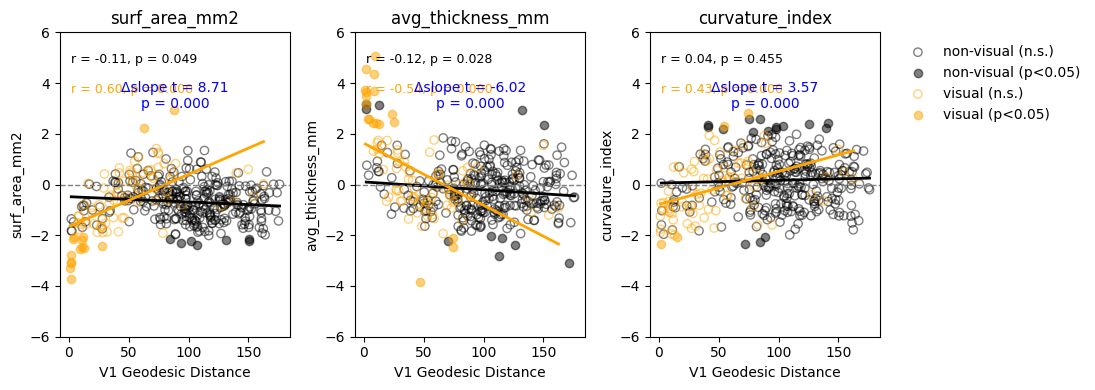

In [31]:
# Define colors and labels for visual groups
colors = {0: 'black', 1: 'orange'} ##D55E00'}
labels = {0: 'non-visual', 1: 'visual'}
#ttest_df = ttest_df[ttest_df.V1<60]

fig, axs = plt.subplots(1, 3, figsize=(9, 4))
ttest_df_copy = ttest_df.copy()
print(ttest_df_copy.shape)
#ttest_df_copy = ttest_df_copy[ttest_df_copy.V1<100] #max(ttest_df_copy[ttest_df_copy.visual == 1].V1)]
#ttest_df_copy = ttest_df_copy[ttest_df_copy.V1ROI==0]
print(ttest_df_copy.shape)

pval = []
for i, ax in enumerate(axs.flatten()):
    for vis_val in [0, 1]:
        # Subset per visual group
        subset = ttest_df_copy[ttest_df_copy.visual == vis_val]
        print(subset.shape)
        x_vals = subset['V1']
        y_vals = subset.iloc[:, i]

        # Correlation
        r, p = pearsonr(x_vals, y_vals)
        pval.append(p)

        # p-values for the same column
        pvals = pvalue_df.iloc[:, i]
        sig_mask = pvals < 0.05
        nonsig_mask = ~sig_mask

        # Scatter: filled for significant, hollow for non-significant
        ax.scatter(
            x_vals[nonsig_mask],
            y_vals[nonsig_mask],
            facecolors='none',
            edgecolors=colors[vis_val],
            alpha=0.5,
            label=f'{labels[vis_val]} (n.s.)'
        )
        ax.scatter(
            x_vals[sig_mask],
            y_vals[sig_mask],
            color=colors[vis_val],
            alpha=0.5,
            label=f'{labels[vis_val]} (p<0.05)'
        )

        # Linear regression line
        slope, intercept = np.polyfit(x_vals, y_vals, 1)
        x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
        y_fit = intercept + slope * x_fit
        ax.plot(x_fit, y_fit, color=colors[vis_val], lw=2)

        # Add r and p text inside subplot
        ax.text(
            0.05, 0.9 - 0.1 * vis_val,
            f"r = {r:.2f}, p = {p:.3f}",
            color=colors[vis_val],
            transform=ax.transAxes,
            fontsize=9
        )

    y_col = network_names[i]

    # Prepare data
    df_model = ttest_df_copy[['V1', 'visual', y_col]].dropna()

    # Design matrix
    X = df_model[['V1', 'visual']].copy()
    X['interaction'] = df_model['V1'] * df_model['visual']
    X = sm.add_constant(X)

    y = df_model[y_col]

    # Fit model
    model = sm.OLS(y, X).fit()

    # Extract interaction term (difference in slopes)
    beta_interaction = model.params['interaction']
    p_interaction = model.pvalues['interaction']
    t_interaction = model.tvalues['interaction']

    # Format axes
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    ax.set_ylim([-6, 6])
    ax.set_xlabel('V1 Geodesic Distance')
    ax.set_ylabel(network_names[i])
    ax.set_title(network_names[i])
    ax.text(
            0.5, 0.75,
            f"Δslope t = {t_interaction:.2f}\np = {p_interaction:.3f}",
            ha='center',
            transform=ax.transAxes,
            fontsize=10,
            color='blue'
       )

# Layout and save
plt.tight_layout()
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [33]:
deaf_sub = pd.read_csv('../Dataset/deaf/Deaf_deaf_subjects', header=None)
control_sub = pd.read_csv('../Dataset/deaf/Deaf_deaf_control_subjects', header=None)
deaf_sub['group'] = 'deaf'
control_sub['group'] = 'deaf_control'
sub = pd.concat([deaf_sub,control_sub])
sub.columns = ['subject', 'group']

In [34]:
all_dfs = {}
for x in ['surf_area_mm2', 'avg_thickness_mm','curvature_index']:
    df_blind = deaf.pivot(index='subject', columns='label', values=x).reset_index()
    df_blind = df_blind.loc[:, ['subject']+list(SA.label.values)]
    df_blind = pd.merge(df_blind, sub, on=['subject'])
    all_dfs[x] = df_blind

In [35]:
parcel_data = []
for roi, df in all_dfs.items():
    df_copy = df.copy()
    df_copy['ROI'] = roi
    parcel_data.append(df_copy)
raw_df = pd.concat(parcel_data, ignore_index=True)

In [36]:
t_all = []
p_all = []
for roi in raw_df['ROI'].unique():
    roi_df = raw_df[raw_df['ROI'] == roi]
    features = roi_df.drop(columns=['group', 'ROI'])
    t = []
    p = []
    for i in np.arange(1,401):
        blind_vals = roi_df[roi_df['group'] == 'deaf'].iloc[:, i].values
        control_vals = roi_df[roi_df['group'] == 'deaf_control'].iloc[:, i].values
        t_stat, p_val = ttest_ind(blind_vals, control_vals, nan_policy='omit')
        t.append(t_stat)
        #t.append(np.mean(blind_vals)-np.mean(control_vals))
        p.append(p_val)
    t_all.append(t)
    p_all.append(p)

In [37]:
ttest_df = pd.DataFrame(t_all).T
ttest_df.columns = raw_df['ROI'].unique()
pvalue_df = pd.DataFrame(p_all).T
pvalue_df.columns = raw_df['ROI'].unique()

In [38]:
ttest_df['SA'] = SA['finalrank.hemisphere'].values
ttest_df['network'] = region_label
ttest_df['auditory'] = auditory
ttest_df['A1'] = geodesicA1 #list(lh_auditory) + list(rh_auditory)
ttest_df['V1'] = geodesicV1 #list(lh_auditory) + list(rh_auditory)
ttest_df['visual'] = visual

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FileNotFoundError: [Errno 2] No such file or directory: '../derivatives/auditory_structural.eps'

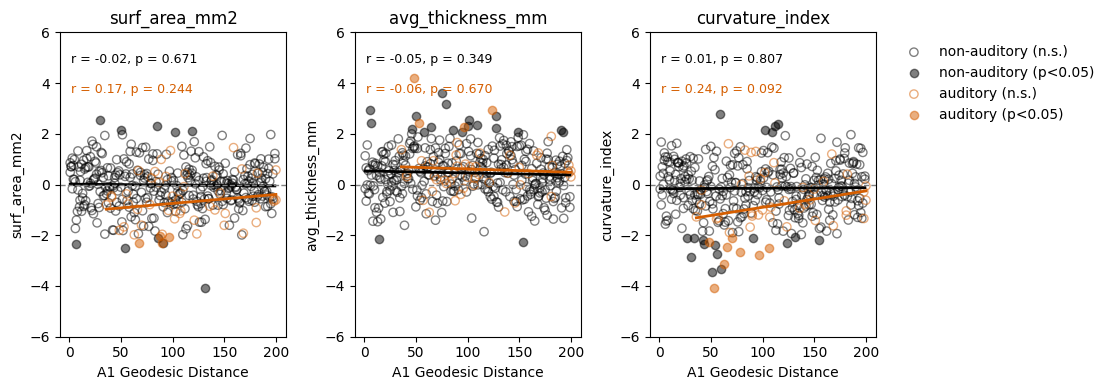

In [ ]:
# Define colors and labels for visual groups
colors = {0: 'black', 1: '#D55E00'}
labels = {0: 'non-auditory', 1: 'auditory'}

fig, axs = plt.subplots(1, 3, figsize=(9, 4))
ttest_df_copy = ttest_df.copy()
#ttest_df_copy = ttest_df_copy[ttest_df_copy.A1<max(ttest_df_copy[ttest_df_copy.auditory == 1].A1)]

pval = []
for i, ax in enumerate(axs.flatten()):
    for vis_val in [0,1]:
        # Subset per visual group
        subset = ttest_df_copy[ttest_df_copy.auditory == vis_val]
        x_vals = subset['SA']
        y_vals = subset.iloc[:, i]

        # Correlation
        r, p = pearsonr(x_vals, y_vals)
        pval.append(p)

        # p-values for the same column
        pvals = pvalue_df.iloc[:, i]
        sig_mask = pvals < 0.05
        nonsig_mask = ~sig_mask

        # Scatter: filled for significant, hollow for non-significant
        ax.scatter(
            x_vals[nonsig_mask],
            y_vals[nonsig_mask],
            facecolors='none',
            edgecolors=colors[vis_val],
            alpha=0.5,
            label=f'{labels[vis_val]} (n.s.)'
        )
        ax.scatter(
            x_vals[sig_mask],
            y_vals[sig_mask],
            color=colors[vis_val],
            alpha=0.5,
            label=f'{labels[vis_val]} (p<0.05)'
        )

        # Linear regression line
        slope, intercept = np.polyfit(x_vals, y_vals, 1)
        x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
        y_fit = intercept + slope * x_fit
        ax.plot(x_fit, y_fit, color=colors[vis_val], lw=2)

        # Add r and p text inside subplot
        ax.text(
            0.05, 0.9 - 0.1 * vis_val,
            f"r = {r:.2f}, p = {p:.3f}",
            color=colors[vis_val],
            transform=ax.transAxes,
            fontsize=9
        )

    # Format axes
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1)
    ax.set_ylim([-6, 6])
    ax.set_xlabel('A1 Geodesic Distance')
    ax.set_ylabel(network_names[i])
    ax.set_title(network_names[i])

# Layout and save
plt.tight_layout()
plt.legend(frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
